# Day-to-day evolution of (ridepooling) supply and demand
Module for simulating ridesourcing evolution, including pooled rides

Contribution by Arjan de Ruijter - a.j.f.deruijter@tudelft.nl

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys # add MaaSSim and MaaSSim/MaaSSim to path (not needed if already in path)
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
from MaaSSim.utils import save_config, get_config, load_G, generate_demand, initialize_df, empty_series, \
    slice_space, test_space, read_requests_csv
from MaaSSim.maassim import Simulator
from MaaSSim.data_structures import structures as inData
from MaaSSim.d2d_sim import *
from MaaSSim.d2d_demand import *
from MaaSSim.d2d_supply import *
from MaaSSim.d2d_shared import prep_shared_rides
from MaaSSim.decisions import dummy_False
from MaaSSim.exmas import main

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
import zipfile
import logging
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
import numpy as np
import random
# import ExMAS
plt.style.use('ggplot')
np.random.seed(0)
random.seed(0)

In [4]:
# Load config
params = get_config('../../data/config/ams.json')  # load configuration
params.paths.albatross = '../../data/albatross'

In [5]:
# Experiment replications and number of threads to be used
params.parallel.nReplications = 1
params.parallel.nThread = 1

# Main experimental settings
params.nP = 1000 # travellers
params.nV = 25 # drivers
params.nD = 3 # days
params.simTime = 2 # hours

In [6]:
# Other day-to-day settings
params.evol.drivers.kappa = 0.2 # learning weight (supply-side)
params.evol.drivers.res_wage.mean = 25 #euros/h
params.evol.drivers.gini = 0.35 # gini coefficient used to establish sigma parameter of log-norm distribution of res wage
params.evol.drivers.init_inc_ratio = 1 #expected income of informed drivers at start of sim as ratio of res wage

params.evol.drivers.inform.prob_start = 1 # probability of being informed at start of sim
params.evol.drivers.inform.beta = 0.1 # information transmission rate
params.evol.drivers.inform.std_fact = 0.5 # multiplier of the standard deviation of experienced income used in signal

params.evol.drivers.regist.prob_start = 1 # probability of being registered if informed at start of sim
params.evol.drivers.regist.beta = 0.2 # registration choice model parameter
params.evol.drivers.regist.cost_comp = 20 # daily share of registration costs (euros)
params.evol.drivers.regist.samp = 0.5 # probability of making (de)regist decision
params.evol.drivers.regist.min_work_exp = 0 # Working experience required before deregistration is possible
params.evol.drivers.regist.min_days = 5 # Minimum number of registered days before driver can deregister

params.evol.drivers.particip.beta = 0.1 # participation choice model parameter
params.evol.drivers.particip.probabilistic = True # stochasticity in participation choice

params.evol.travellers.inform.prob_start = 1 # probability that traveller is informed at start of sim
params.evol.travellers.inform.beta = 0.1 # information transmission rate (demand-side)
params.evol.travellers.inform.start_wait = 0 # expected waiting time at start of simulation
params.evol.travellers.inform.std_fact = 0.5 # multiplier of the standard deviation of experienced waiting time used in signal
params.evol.travellers.reject_penalty = 30 * 60 # seconds
params.evol.travellers.kappa = 0.2 # learning weight (demand-side)
params.evol.travellers.min_prob = 0.05 # filtering criterion, when probability is lower when waiting time is zero, never consider RS

params.evol.travellers.mode_pref.mean_vot = 10 # Mean VoT in euro/h
params.evol.travellers.mode_pref.access_multip = 2 # Multiplier of access time compared to in-vehicle time
params.evol.travellers.mode_pref.wait_multip = 2.5 # Multiplier of waiting time compared to in-vehicle time
params.evol.travellers.mode_pref.bike_multip = 2 # Multiplier of biking time compared to in-vehicle time
params.evol.travellers.mode_pref.beta_cost = -0.364 #-0.296 # -0.148 # util/euro #-0.1592
params.evol.travellers.mode_pref.transfer_pen = 5 * 60 # seconds, to be added to IVT for each transfer
params.evol.travellers.mode_pref.ASC_car = -1.683 #-0.159 # -1.216 # util, rel to bike
params.evol.travellers.mode_pref.ASC_rs = -4.599 #-2.419 #-3.172
params.evol.travellers.mode_pref.ASC_pt = -3.724 #-1.782 #-2.303
params.evol.travellers.mode_pref.ASC_car_sd = 2.647 #3.338 # standard deviation in ASCs
params.evol.travellers.mode_pref.ASC_rs_sd = 1.682 #2.068 #1
params.evol.travellers.mode_pref.ASC_pt_sd = 1.355 #2.341 #1
params.evol.travellers.mode_pref.ASC_bike_sd = 5.570 #0 #1
params.evol.travellers.mode_pref.gini = params.evol.drivers.gini

# Financial settings
params.platforms.base_fare = 1.5 #euro
params.platforms.fare = 1.5 #euro/km
params.platforms.min_fare = 0 # euro
params.platforms.comm_rate = 0.25 #rate
params.drivers.fuel_costs = 0.25 #euro/km

# Properties alternative modes
params.alt_modes.pt.option = False
params.alt_modes.pt.base_fare = 1 # euro
params.alt_modes.pt.km_fare = 0.2 # euro/km
params.alt_modes.car.km_cost = 0.5 # euro/km
params.alt_modes.car.diff_parking = True # different parking tariffs in city
params.alt_modes.car.park_cost = 7.5 # euro
params.alt_modes.car.park_cost_center = 15 # euro
params.alt_modes.car.access_time = 10 * 60 # s
params.speeds.bike = (1/2.5) * params.speeds.ride # m/s

# Regulation
params.platforms.reg_cap = np.inf # registration cap
params.platforms.ptcp_cap = np.inf # daily participation cap

# Demand settings
# params.demand_structure.origins_dispertion = -0.0003
# params.demand_structure.destinations_dispertion = -0.0003
params.dist_threshold_min = 2000 # min dist
# params.dist_threshold = 100000 # max dist

# Start time
# params.t0 = pd.Timestamp.now()
params.t0 = pd.Timestamp(2021, 11, 1, 9)

In [7]:
# Pooling settings
params.shareability.offered = True
params.shareability.min_discount = 0.25 # fraction of solo fare
params.shareability.add_discount = 0.25 # fraction of solo fare
params.shareability.shared_discount = params.shareability.min_discount # as considered by platform in determ. of feasible rides (fraction of solo fare), currently not used
params.shareability.delay_value = 1 # currently not used
params.shareability.WtS_mean = 1.5 # Actual (mean) WtS multipl. in population
params.shareability.WtS = 1 # Willingness to share multipl. as considered by platform in determining feasible rides
params.shareability.sharing_constant = -0.251 #-0.215 #-0.215 #util, rel. to private ride
params.shareability.sharing_const_sd = 0 #0.065
params.shareability.WtS_std = 0 # St. dev. of WtS in population
params.shareability.matching_obj = 'u_pax' #minimize VHT for vehicles
params.shareability.pax_delay = 0 # additional delay for picking up travs
params.shareability.max_delay = 10 * 60 # max. allowed delay in pooled rides (seconds)
params.shareability.horizon = 600
params.shareability.max_degree = 3
params.shareability.share = 1
params.shareability.without_matching = True

In [8]:
# Compute (other) input parameters in ExMAS
params.shareability.avg_speed = params.speeds.ride
params.shareability.price = params.platforms.fare #eur/km
params.shareability.nP = params.nP
params.shareability.VoT = params.evol.travellers.mode_pref.mean_vot / 3600 # convert eur/h to eur/s   # not used?

In [9]:
inData = load_G(inData, params, stats=True, set_t=False)  # download graph for the 'params.city' and calc the skim matrices
if params.alt_modes.car.diff_parking:
    inData = diff_parking(inData) # determine which nodes are in center

In [10]:
inData = generate_demand(inData, params, avg_speed = True)

In [11]:
if params.alt_modes.pt.option:
    # Load processed Albatross file, the OTP result, and compute PT fares
    inData = load_albatross_proc(inData, params, avg_speed = True)
    inData.requests = inData.requests.drop(['orig_geo', 'dest_geo', 'origin_y', 'origin_x', 'destination_y', 'destination_x', 'time'], axis = 1)
    inData.pt_itinerary = load_OTP_result(params)
    inData = consist_OTP_alba(inData, params)

In [12]:
# Prepare supply and demand attributes
inData.passengers = prefs_travs(inData, params) # Draw mode preferences and determine utilities of alternative modes
all_pax = mode_filter(inData, params) # Determine probability to choose ride-hailing without waiting time and delay
inData.passengers = all_pax[all_pax.mode_choice == "day-to-day"] # Select those with significant probability to choose ride-hailing
inData.requests = inData.requests[inData.requests.pax_id.isin(inData.passengers.index)] # Select requests accordingly
if params.alt_modes.pt.option:
    inData.pt_itinerary = inData.pt_itinerary[inData.pt_itinerary.pax_id.isin(inData.passengers.index)]
    inData.pt_itinerary.reset_index(drop=True, inplace=True)
inData.passengers.reset_index(drop=True, inplace=True)
inData.requests.reset_index(drop=True, inplace=True)
inData.requests['pax_id'] = inData.requests.index
inData.pt_itinerary['pax_id'] = inData.pt_itinerary.index
inData.passengers['informed'] = np.random.rand(len(inData.passengers)) < params.evol.travellers.inform.prob_start
inData.passengers['expected_wait'] = params.evol.travellers.inform.start_wait
inData.passengers['expected_wait_pool'] = params.evol.travellers.inform.start_wait
inData.passengers['expected_pool_disc'] = params.shareability.min_discount
inData.passengers['expected_pool_detour'] = 0
fixed_supply = generate_vehicles_d2d(inData, params) # generate vehicle data
inData.vehicles = fixed_supply.copy()
inData.vehicles.platform = inData.vehicles.apply(lambda x: 0, axis = 1)
inData.passengers.platforms = inData.passengers.apply(lambda x: [0], axis = 1)
inData.requests['platform'] = inData.requests.apply(lambda row: inData.passengers.loc[row.name].platforms[0], axis = 1) 
inData.platforms = pd.concat([inData.platforms,pd.DataFrame(columns=['base_fare','comm_rate','min_fare'])])
inData.platforms = initialize_df(inData.platforms)
inData.platforms.loc[0]=[params.platforms.fare,'Uber',30,params.platforms.base_fare,params.platforms.comm_rate,params.platforms.min_fare,]

In [13]:
inData = main(inData, params.shareability, plot=False) # create shareability graph (ExMAS), i.e. set of feasible pooled rides 

31-05-23 10:36:54-INFO-Initializing pairwise trip shareability between 1000 and 1000 trips.
31-05-23 10:36:54-INFO-creating combinations
31-05-23 10:36:55-INFO-138012	 nR*(nR-1)
31-05-23 10:37:05-INFO-Reduction of feasible pairs by 99.59%
31-05-23 10:37:05-INFO-Degree 2 	Completed
31-05-23 10:37:05-INFO-trips to extend at degree 2 : 9420
31-05-23 10:39:31-INFO-At degree 2 feasible extensions found out of 30026 searched
31-05-23 10:39:31-INFO-Degree 3 	Completed
31-05-23 10:39:31-INFO-Max degree reached 3
31-05-23 10:39:31-INFO-Trips still possible to extend at degree 3 : 30026


In [14]:
# Day-to-day simulation (incl. processing)
sim = Simulator(inData, params=params,
                    kpi_veh = D2D_veh_exp,
                    kpi_pax = d2d_kpi_pax,
                    f_driver_out = D2D_driver_out,
                    f_trav_out = d2d_no_request,
                    f_trav_mode = dummy_False,
                    logger_level=logging.WARNING)  # initialize

evol_micro = init_d2d_dotmap(params)
plf_stats = pd.DataFrame(columns = ['profit','veh_dist','pax_dist'])
for day in range(params.get('nD', 1)):  # run iterations
    inData.passengers = mode_preday(inData, params)
    temp_rides = inData.sblts.rides.copy()
    temp_reqs = inData.sblts.requests.copy()
    
    rs_users = inData.passengers[(inData.passengers.mode_day == 'rs') | (inData.passengers.mode_day == 'pool')].index.tolist()
    poolers = inData.passengers[inData.passengers.mode_day == 'pool'].index.tolist()
    inData.sblts.rides = inData.sblts.rides[inData.sblts.rides.apply(lambda x: all(i in rs_users for i in x.indexes), axis=1)] # filter out all travellers opting for mode outside ride-hailing market
    inData.sblts.rides = inData.sblts.rides[inData.sblts.rides.apply(lambda x: (all(i in poolers for i in x.indexes) or x.kind == 1), axis=1)]  # filter out pooled option for individuals opting for private ride
    inData.sblts.requests = inData.sblts.requests[inData.sblts.requests.apply(lambda x: x.pax_id in rs_users, axis=1)]
    
    inData = prep_shared_rides(inData, params.shareability)  # prepare schedules
    sim.make_and_run(run_id=day)  # prepare and SIM
    sim.output()  # calc results
    sim.last_res = sim.res[day].copy()
    del sim.res[day]

    drivers_summary = update_d2d_drivers(sim=sim,params=params)
    travs_summary = update_d2d_travellers(sim=sim,params=params)
    
    exp_df = update_work_exp(inData, drivers_summary)
    inData.vehicles.work_exp = exp_df.work_exp
    inData.days_since_reg = exp_df.days_since_reg

    res_inf_driver = wom_driver(inData, params = params)
    inData.vehicles.informed = res_inf_driver
    inData.vehicles.expected_income = learning_unregist(inData, drivers_summary, params = params)
    
    res_regist = platform_regist(inData, drivers_summary, params = params)
    inData.vehicles.registered = res_regist.registered
    inData.vehicles.work_exp = res_regist.work_exp
    inData.vehicles.pos = fixed_supply.pos
    inData.vehicles.rejected_reg = res_regist.rejected_reg
    
    res_inf_trav = wom_trav(inData, travs_summary, params = params)
    inData.passengers.informed = res_inf_trav.informed
    inData.passengers.expected_wait = res_inf_trav.perc_wait
    inData.passengers.expected_wait_pool = res_inf_trav.perc_wait_pool
    inData.passengers.expected_pool_disc = res_inf_trav.perc_disc
    inData.passengers.expected_pool_detour = res_inf_trav.perc_detour
    
    inData.sblts.rides = temp_rides.copy()
    inData.sblts.requests = temp_reqs.copy()
    
    evol_micro = d2d_summary_day(evol_micro, drivers_summary, travs_summary, day)
    evol_micro = d2d_summ_pooling(evol_micro, travs_summary)
    row = {'profit': sim.last_res.veh_kpi.REVENUE.loc['sum'] / (1 - params.platforms.comm_rate), 'veh_dist': sim.last_res.veh_kpi.DRIVING_DIST.loc['sum'], 'pax_dist': sim.last_res.pax_kpi.TRAVEL.loc['sum'] * params.speeds.ride / 1000}
    plf_stats = plf_stats.append(row, ignore_index=True)

31-05-23 09:36:40-WARNING-Setting up 2h simulation at 2021-11-01 08:00:10 for 25 vehicles and 1000 passengers in Amsterdam, Netherlands
31-05-23 09:36:55-WARNING-day 0: simulation time 9.0 s
31-05-23 09:36:55-WARNING-assertion tests for simulation results - passed
31-05-23 09:37:09-WARNING-day 1: simulation time 8.4 s
31-05-23 09:37:09-WARNING-assertion tests for simulation results - passed
31-05-23 09:37:22-WARNING-day 2: simulation time 8.7 s
31-05-23 09:37:23-WARNING-assertion tests for simulation results - passed


In [15]:
evol_micro, evol_agg = d2d_agg_statistics(evol_micro, params) # multi-day stats

In [16]:
# Save d2d stats to zip file
with zipfile.ZipFile('evol.zip', 'w') as csv_zip:
    csv_zip.writestr("evol_agg_supply.csv", evol_agg.supply.to_csv())
    csv_zip.writestr("evol_agg_demand.csv", evol_agg.demand.to_csv())

In [17]:
evol_agg.supply

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc
day,,,,,,,,,
0,25,25,0,14,0,47.093350,39.143469,47.093350,35.614286
1,25,25,0,13,0,46.698082,39.318517,46.698082,33.817404
2,25,25,0,14,0,46.125966,41.077585,46.125966,34.388750


In [18]:
evol_agg.demand

,inform,requests,req_solo,req_pool,gets_offer_solo,gets_offer_pooling,act_shared,mean_wait_solo,corr_mean_wait_solo,mean_wait_pooling,corr_mean_wait_pooling,perc_wait,perc_wait_req,perc_wait_pool,mean_disc,perc_disc,mean_detour,perc_detour,bike,car,pt
day,,,,,,,,,,,,,,,,,,,,,
0,372,153,58,95,53,87,84,627.300000,726.941176,445.450000,501.718954,0.000000,0.000000,0.000000,0.471053,0.250000,70.435714,0.000000,145,74,0
1,372,135,77,58,73,46,39,494.378151,649.118519,216.840336,351.140741,18.526344,34.964444,41.270430,0.418103,0.261290,45.815126,5.418132,166,71,0
2,372,134,95,39,90,32,26,524.459016,638.686567,177.196721,255.358209,39.541613,69.520896,66.586882,0.416667,0.266505,26.770492,8.700568,160,78,0


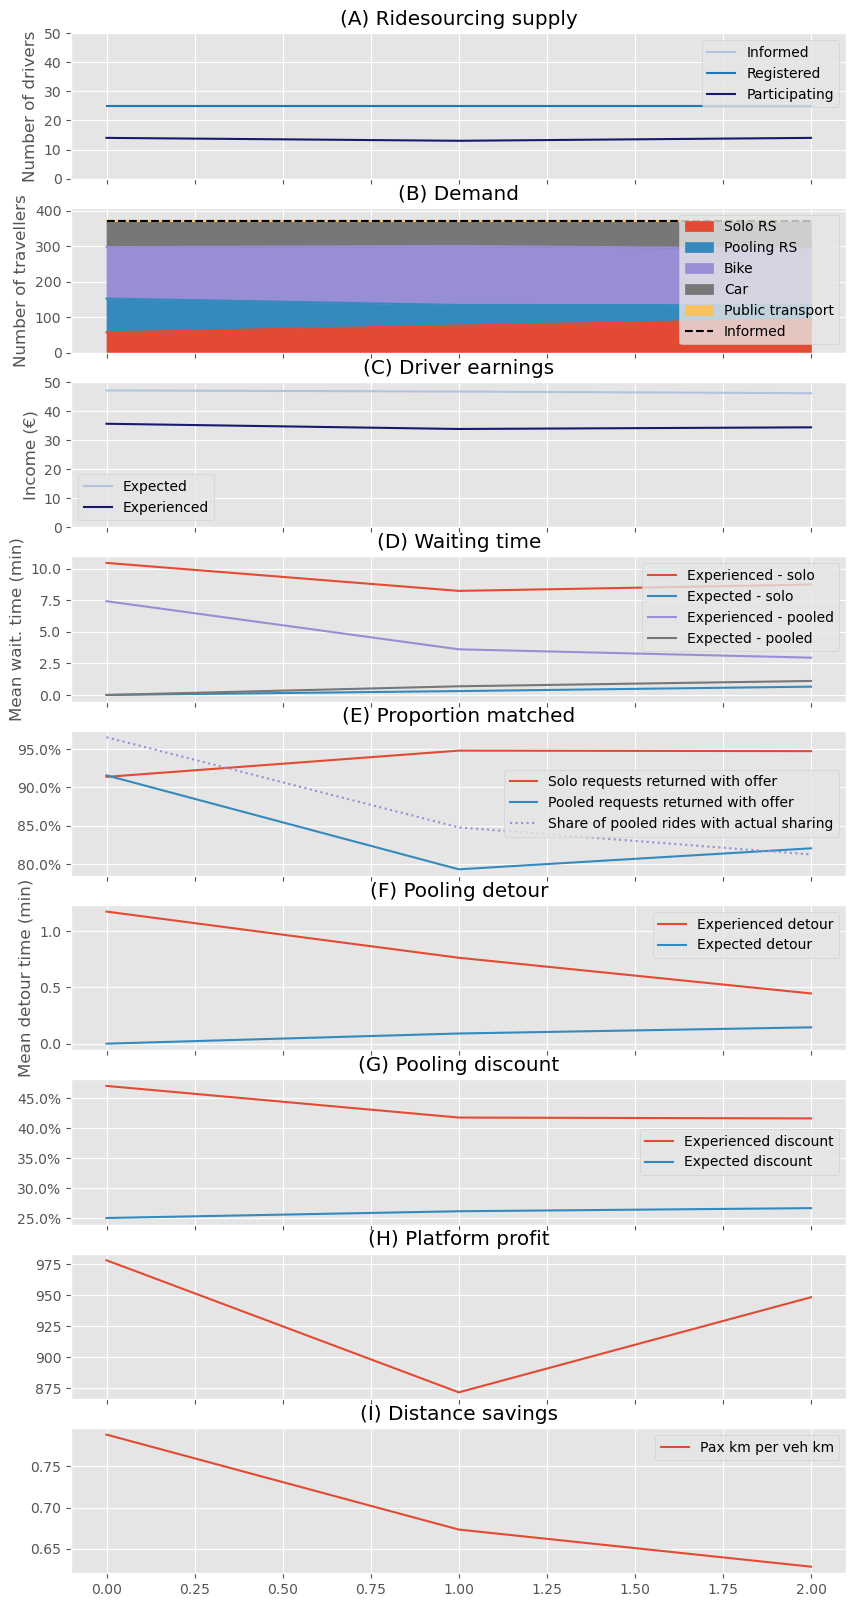

In [19]:
# Plot evolution of main performance indicators
fig, axes = plt.subplots(nrows=9, ncols=1, figsize = (10,20), sharex = True)
evol_agg.supply[['inform','regist','particip']].plot(ax = axes[0], color=['lightsteelblue','tab:blue','midnightblue'])
axes[0].set_title('(A) Ridesourcing supply')
axes[0].legend(['Informed','Registered','Participating'])
axes[0].set_ylim([0,params.nV + 25])
axes[0].set_ylabel('Number of drivers')
evol_agg.supply[['mean_perc_inc','mean_exp_inc']].plot(ax = axes[2], color=['lightsteelblue','midnightblue'])
axes[2].set_title('(C) Driver earnings')
axes[2].legend(['Expected','Experienced'])
axes[2].set_ylim([0,math.ceil(max(evol_agg.supply.mean_perc_inc.max(),evol_agg.supply.mean_exp_inc.max())/50)*50])
axes[2].set_ylabel('Income (\u20ac)')

evol_agg.demand[['req_solo','req_pool','bike','car','pt']].plot.area(ax = axes[1])
h,l = axes[1].get_legend_handles_labels()
evol_agg.demand['inform'].plot(ax = axes[1], color = 'black', linestyle = 'dashed', label = 'informed')
line = Line2D([0], [0],color='black', linestyle ='dashed')
axes[1].set_title('(B) Demand')
axes[1].set_ylim([0,len(inData.passengers) * 1.1])
axes[1].set_ylabel('Number of travellers')
h.extend([line])
axes[1].legend(labels=["Solo RS","Pooling RS","Bike","Car","Public transport","Informed"], handles=h)

evol_agg.demand['mean_wait_solo'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Experienced - solo')
# evol_agg.demand['corr_mean_wait_solo'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Corrected exp. - solo')
evol_agg.demand['perc_wait'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Expected - solo')
evol_agg.demand['mean_wait_pooling'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Experienced - pooled')
# evol_agg.demand['corr_mean_wait_pooling'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Corrected exp. - pooled')
evol_agg.demand['perc_wait_pool'].apply(lambda x: 1/60 * x).plot(ax = axes[3], label='Expected - pooled')
axes[3].legend()
axes[3].set_title('(D) Waiting time')
axes[3].set_ylabel('Mean wait. time (min)')

evol_agg.demand['proport_match_solo'] = evol_agg.demand.gets_offer_solo / evol_agg.demand.req_solo * 100
evol_agg.demand['proport_match_pool'] = evol_agg.demand.gets_offer_pooling / evol_agg.demand.req_pool * 100
evol_agg.demand['act_shared_rel'] = evol_agg.demand.act_shared / evol_agg.demand.gets_offer_pooling * 100
evol_agg.demand['proport_match_solo'].plot(ax = axes[4], label='Solo requests returned with offer')
evol_agg.demand['proport_match_pool'].plot(ax = axes[4], label='Pooled requests returned with offer')
evol_agg.demand['act_shared_rel'].plot(ax = axes[4], label='Share of pooled rides with actual sharing', linestyle = 'dotted')
axes[4].legend()
axes[4].set_title('(E) Proportion matched')
axes[4].yaxis.set_major_formatter(mtick.PercentFormatter())

evol_agg.demand['mean_detour'].apply(lambda x: 1/60 * x).plot(ax = axes[5], label='Experienced detour')
evol_agg.demand['perc_detour'].apply(lambda x: 1/60 * x).plot(ax = axes[5], label='Expected detour')
axes[5].legend()
axes[5].set_title('(F) Pooling detour')
axes[5].set_ylabel('Mean detour time (min)')

evol_agg.demand['mean_disc'].apply(lambda x: 100 * x).plot(ax = axes[6], label='Experienced discount')
evol_agg.demand['perc_disc'].apply(lambda x: 100 * x).plot(ax = axes[6], label='Expected discount')
axes[6].legend()
axes[6].set_title('(G) Pooling discount')
axes[6].yaxis.set_major_formatter(mtick.PercentFormatter())

plf_stats['profit'].plot(ax = axes[7], label='Platform profit')
axes[7].set_title('(H) Platform profit')

plf_stats['dist_ratio'] = plf_stats.pax_dist / plf_stats.veh_dist
plf_stats['dist_ratio'].plot(ax = axes[8], label='Pax km per veh km')
axes[8].legend()
axes[8].set_title('(I) Distance savings')

plt.savefig('d2d-evo.png')
plt.show()

---

In [20]:
sim.last_res.veh_exp

,nRIDES,nREJECTED,DRIVING_TIME,DRIVING_DIST,REVENUE,COST,NET_INCOME,OUT,FORCED_OUT,STARTS_DAY,OPENS_APP,RECEIVES_REQUEST,ACCEPTS_REQUEST,REJECTS_REQUEST,IS_ACCEPTED_BY_TRAVELLER,IS_REJECTED_BY_TRAVELLER,ARRIVES_AT_PICKUP,MEETS_TRAVELLER_AT_PICKUP,DEPARTS_FROM_PICKUP,ARRIVES_AT_DROPOFF,CONTINUES_SHIFT,STARTS_REPOSITIONING,REPOSITIONED,DECIDES_NOT_TO_DRIVE,ENDS_SHIFT,NOT_ALLOWED_TO_DRIVE
veh,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.00,0.00000,0.0000,0.00000,True,False,0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
2,8.0,0.0,6817.0,68.17,48.80250,17.0425,31.76000,False,False,0,765.0,44.0,160.0,0,3279.0,0,0.0,240.0,3538.0,6373.0,0,0,0,0,0,0
3,0.0,0.0,0.0,0.00,0.00000,0.0000,0.00000,True,False,0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
4,12.0,0.0,7256.0,72.56,60.49125,18.1400,42.35125,False,False,0,121.0,45.0,200.0,0,3079.0,0,0.0,360.0,4177.0,6417.0,0,0,0,0,0,0
5,0.0,0.0,0.0,0.00,0.00000,0.0000,0.00000,True,False,0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
6,8.0,0.0,6842.0,68.42,50.05125,17.1050,32.94625,False,False,0,736.0,30.0,140.0,0,3193.0,0,0.0,240.0,3649.0,6411.0,0,0,0,0,0,0
7,9.0,0.0,6757.0,67.57,55.40625,16.8925,38.51375,False,False,0,255.0,30.0,180.0,0,2732.0,0,0.0,270.0,4025.0,6907.0,0,0,0,0,0,0
8,0.0,0.0,0.0,0.00,0.00000,0.0000,0.00000,True,False,0,0.0,0.0,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0
9,8.0,0.0,6447.0,64.47,44.80875,16.1175,28.69125,False,False,0,533.0,30.0,140.0,0,3264.0,0,0.0,240.0,3183.0,7009.0,0,0,0,0,0,0


In [21]:
sim.last_res.pax_exp

,ACCEPTS_OFFER,ARRIVES_AT_DEST,ARRIVES_AT_DROPOFF,ARRIVES_AT_PICKUP,DEPARTS_FROM_PICKUP,LOSES_PATIENCE,MEETS_DRIVER_AT_PICKUP,PREFERS_OTHER_SERVICE,RECEIVES_OFFER,REQUESTS_RIDE,SETS_OFF_FOR_DEST,NO_REQUEST,OTHER_MODE,STARTS_DAY,IS_REJECTED_BY_VEHICLE,REJECTS_OFFER,TRAVEL,WAIT,OPERATIONS
pax,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0
368,0.0,0.0,460.0,20.0,30.0,0.0,538.0,0.0,276.0,7069.0,10.0,False,False,0,0,0,460.0,814.0,40.0
369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0,0,0,0.0,0.0,0.0


In [22]:
inData.sblts.R[1]

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest
0,[0],14.311111,805,1,[14.31111111111111],"[0, 805]",[0],[0]
1,[1],11.549778,649,1,[11.549777777777777],"[5, 649]",[1],[1]
2,[2],6.733500,378,1,[6.7335],"[24, 378]",[2],[2]
3,[3],6.140833,345,1,[6.140833333333333],"[63, 345]",[3],[3]
4,[4],3.669722,206,1,[3.6697222222222226],"[78, 206]",[4],[4]
...,...,...,...,...,...,...,...,...
367,[367],8.041556,452,1,[8.041555555555554],"[7067, 452]",[367],[367]
368,[368],8.179278,460,1,[8.179277777777779],"[7069, 460]",[368],[368]
369,[369],10.383722,584,1,[10.383722222222222],"[7084, 584]",[369],[369]
370,[370],5.284500,297,1,[5.2845],"[7098, 297]",[370],[370]


In [23]:
inData.sblts.rides

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest,degree,index
0,[0],14.311111,805,1,[14.31111111111111],"[0, 805]",[0],[0],1.0,0
1,[1],11.549778,649,1,[11.549777777777777],"[5, 649]",[1],[1],1.0,1
2,[2],6.733500,378,1,[6.7335],"[24, 378]",[2],[2],1.0,2
3,[3],6.140833,345,1,[6.140833333333333],"[63, 345]",[3],[3],1.0,3
4,[4],3.669722,206,1,[3.6697222222222226],"[78, 206]",[4],[4],1.0,4
...,...,...,...,...,...,...,...,...,...,...
39813,"[304, 298, 323]",29.799667,1931,32,"[17.503805555555555, 8.052305555555556, 4.2435...","[5789.0, 233, 458, 111, 308, 821]","[304, 298, 323]","[298, 323, 304]",NaN,39813
39814,"[304, 298, 326]",31.075583,1881,32,"[17.431583333333336, 8.232861111111111, 5.4111...","[5789.0, 233, 396, 214, 285, 753]","[304, 298, 326]","[298, 326, 304]",NaN,39814
39815,"[304, 330, 331]",28.661083,1958,32,"[18.23575, 6.824222222222223, 3.6011111111111114]","[5997.5, 409, 485, 134, 136, 794]","[304, 330, 331]","[330, 331, 304]",NaN,39815
39816,"[304, 330, 332]",29.784264,1911,32,"[18.105194444444443, 6.902000000000001, 4.7770...","[5997.5, 409, 455, 192, 120, 735]","[304, 330, 332]","[330, 332, 304]",NaN,39816


In [24]:
inData.sblts.requests

,index,pax_id,origin,destination,treq,tdep,ttrav,tarr,tdrop,shareable,schedule_id,dist,car_park_cost,dest_center,platform,VoT,delta,u,u_PT
0,0,0,252315496,46380158,0,NaN,805,2021-11-01 08:13:35,NaN,False,NaN,8050,15.0,True,0,0.002778,600.000,14.311111,999999
1,1,1,4422115072,46351183,5,NaN,649,2021-11-01 08:11:04,NaN,False,NaN,6498,15.0,True,0,0.002778,600.000,11.549778,999999
2,2,2,46257961,46380093,24,NaN,378,2021-11-01 08:06:52,NaN,False,NaN,3789,15.0,True,0,0.002778,511.515,6.733500,999999
3,3,3,46332982,46314424,63,NaN,345,2021-11-01 08:06:58,NaN,False,NaN,3455,7.5,False,0,0.002778,466.425,6.140833,999999
4,4,4,46380158,46424347,78,NaN,206,2021-11-01 08:04:54,NaN,False,NaN,2065,15.0,True,0,0.002778,278.775,3.669722,999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,367,367,506965966,46372928,7067,NaN,452,2021-11-01 10:05:29,NaN,False,NaN,4524,15.0,True,0,0.002778,600.000,8.041556,999999
368,368,368,6235704571,46379144,7069,NaN,460,2021-11-01 10:05:39,NaN,False,NaN,4601,15.0,True,0,0.002778,600.000,8.179278,999999
369,369,369,46302615,46426761,7084,NaN,584,2021-11-01 10:07:58,NaN,False,NaN,5841,15.0,True,0,0.002778,600.000,10.383722,999999
370,370,370,46409976,46326256,7098,NaN,297,2021-11-01 10:03:25,NaN,False,NaN,2973,7.5,False,0,0.002778,401.355,5.284500,999999


In [25]:
sim.runs[0].rides

,veh,pos,t,event,paxes
0,22,4.631131e+07,0,STARTS_DAY,[]
1,22,4.631131e+07,0,DECIDES_NOT_TO_DRIVE,[]
0,11,2.054128e+09,0,STARTS_DAY,[]
1,11,2.054128e+09,0,OPENS_APP,[]
2,11,2.054128e+09,226,RECEIVES_REQUEST,[]
...,...,...,...,...,...
60,3,4.636370e+07,7996,MEETS_TRAVELLER_AT_PICKUP,[359]
61,3,4.636370e+07,8026,DEPARTS_FROM_PICKUP,"[359, 361]"
62,3,2.020569e+09,8233,ARRIVES_AT_DROPOFF,"[359, 361]"
63,3,4.631541e+07,8534,ARRIVES_AT_DROPOFF,[361]


In [26]:
sim.runs[0].trips

,pax,pos,t,event,veh_id
0,0,252315496,0,STARTS_DAY,NaN
1,0,252315496,0,REQUESTS_RIDE,NaN
2,0,252315496,0,RECEIVES_OFFER,NaN
3,0,252315496,15,ACCEPTS_OFFER,NaN
4,0,252315496,35,ARRIVES_AT_PICKUP,18.0
...,...,...,...,...,...
5,371,46453469,8065,MEETS_DRIVER_AT_PICKUP,12.0
6,371,46453469,8095,DEPARTS_FROM_PICKUP,12.0
7,371,46295651,9078,ARRIVES_AT_DROPOFF,12.0
8,371,46295651,9088,SETS_OFF_FOR_DEST,NaN


In [27]:
inData.sblts.SINGLES

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest
0,[0],14.311111,805,1,[14.31111111111111],"[0, 805]",[0],[0]
1,[1],11.549778,649,1,[11.549777777777777],"[5, 649]",[1],[1]
2,[2],6.733500,378,1,[6.7335],"[24, 378]",[2],[2]
3,[3],6.140833,345,1,[6.140833333333333],"[63, 345]",[3],[3]
4,[4],3.669722,206,1,[3.6697222222222226],"[78, 206]",[4],[4]
...,...,...,...,...,...,...,...,...
367,[367],8.041556,452,1,[8.041555555555554],"[7067, 452]",[367],[367]
368,[368],8.179278,460,1,[8.179277777777779],"[7069, 460]",[368],[368]
369,[369],10.383722,584,1,[10.383722222222222],"[7084, 584]",[369],[369]
370,[370],5.284500,297,1,[5.2845],"[7098, 297]",[370],[370]


In [28]:
xyz = inData.sblts.rides[inData.sblts.rides.apply(lambda x: all(i in rs_users for i in x.indexes), axis=1)] # filter out all travellers opting for mode outside ride-hailing market
xyz = xyz[xyz.apply(lambda x: (all(i in poolers for i in x.indexes) or x.kind == 1), axis=1)]  # filter out pooled trips for individuals opting for private ride
xyz
# poolers

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest,degree,index
5,[5],11.398556,641,1,[11.398555555555555],"[121, 641]",[5],[5],1.0,5
7,[7],7.671222,431,1,[7.671222222222222],"[169, 431]",[7],[7],1.0,7
10,[10],4.773444,268,1,[4.773444444444444],"[237, 268]",[10],[10],1.0,10
12,[12],5.231167,294,1,[5.231166666666667],"[248, 294]",[12],[12],1.0,12
13,[13],13.666833,768,1,[13.666833333333333],"[255, 768]",[13],[13],1.0,13
...,...,...,...,...,...,...,...,...,...,...
23120,"[32, 22, 39]",14.081028,709,30,"[4.15425, 3.7328055555555557, 6.193972222222222]","[517.0, 93, 151, 143, 41, 281]","[32, 22, 39]","[32, 22, 39]",NaN,23120
31192,"[32, 22, 25]",12.334625,641,30,"[4.165361111111111, 3.3994722222222222, 4.7697...","[517.0, 93, 204, 31, 43, 270]","[32, 22, 25]","[22, 32, 25]",NaN,31192
33322,"[263, 254, 268]",28.319222,1668,30,"[12.468097222222223, 7.526319444444444, 8.3248...","[4902.0, 415, 487, 124, 193, 449]","[263, 254, 268]","[254, 263, 268]",NaN,33322
36043,"[39, 32, 25]",16.065236,771,30,"[7.0273055555555555, 3.8014722222222224, 5.236...","[654.0, 139, 182, 74, 273, 103]","[39, 32, 25]","[32, 39, 25]",NaN,36043


In [29]:
xyz = inData.sblts.schedule.copy()
xyz['pooling_reqs'] = xyz.apply(lambda x: any(i in travs_summary[travs_summary.chosen_mode == 'pool'].index.to_list() for i in x.indexes) and travs_summary.gets_offer.loc[x.indexes[0]], axis=1)
xyz[xyz.pooling_reqs]

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest,degree,index,lambda_r,PassHourTrav_ns,row,selected,nodes,req_id,sim_schedule,pooling_reqs
54,[54],4.026778,226,1,[4.026777777777777],"[957, 226]",[54],[54],1,54,0.250000,226,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[None, 1029673119, 1746135649]","[None, 54, 54]",node time req_id od 0 ...,True
175,[175],9.902222,557,1,[9.902222222222223],"[3292, 557]",[175],[175],1,175,0.250000,557,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[None, 46442263, 2300846515]","[None, 175, 175]",node time req_id od 0 ...,True
225,[225],6.483111,364,1,[6.4831111111111115],"[4242, 364]",[225],[225],1,225,0.250000,364,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[None, 46373209, 46274584]","[None, 225, 225]",node time req_id od 0 NaN...,True
269,[269],5.859389,329,1,[5.859388888888889],"[5320, 329]",[269],[269],1,269,0.250000,329,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[None, 46351185, 1624052865]","[None, 269, 269]",node time req_id od 0 ...,True
326,[326],5.763000,324,1,[5.763000000000001],"[6360, 324]",[326],[326],1,326,0.250000,324,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[None, 46345192, 46363900]","[None, 326, 326]",node time req_id od 0 NaN...,True
368,[368],8.179278,460,1,[8.179277777777779],"[7069, 460]",[368],[368],1,368,0.250000,460,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[None, 6235704571, 46379144]","[None, 368, 368]",node time req_id od 0 ...,True
990,"[22, 25]",7.822042,506,20,"[3.355027777777778, 4.467013888888889]","[361.0, 204, 31, 271]","[22, 25]","[22, 25]",2,990,0.030651,522,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",1,"[None, 1222424063, 1069290042, 2311168469, 463...","[None, 22, 25, 22, 25]",node time req_id od 0 ...,True
1060,"[254, 268]",15.734458,1139,20,"[7.804097222222222, 7.930361111111111]","[4909.0, 487, 124, 528]","[254, 268]","[254, 268]",2,1060,-0.117763,1019,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[None, 46403224, 46435490, 2092517865, 46325415]","[None, 254, 268, 254, 268]",node time req_id od 0 ...,True
1239,"[351, 349]",18.589361,1117,20,"[10.404, 8.185361111111112]","[6551.0, 478, 481, 158]","[351, 349]","[351, 349]",2,1239,0.011504,1130,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[None, 1139517348, 46343767, 46322347, 46341917]","[None, 351, 349, 351, 349]",node time req_id od 0 ...,True
1616,"[137, 157]",11.139583,771,20,"[3.917736111111111, 7.221847222222222]","[2618.0, 246, 149, 376]","[137, 157]","[137, 157]",2,1616,-0.064917,724,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1,"[None, 46437772, 46392019, 1367613849, 46355204]","[None, 137, 157, 137, 157]",node time req_id od 0 ...,True


In [30]:
inData.passengers.head(50)

,pos,event,platforms,ASC_bike,ASC_car,ASC_pt,VoT,U_bike,U_car,U_pt,ASC_rs,ASC_pool,mode_choice,prob_rs,prob_pool,informed,expected_wait,expected_wait_pool,expected_pool_disc,expected_pool_detour,mode_day
pax,,,,,,,,,,,,,,,,,,,,,
0,252315496,NaN,[0],-3.269107,-7.987493,-4.737945,4.977518,-5.294819,-15.921674,-99999,-2.742338,-2.993338,day-to-day,0.037665,0.346669,True,112.20,0.00,0.25,0.0,bike
1,4422115072,NaN,[0],-10.851341,-0.425604,-3.327160,6.138601,-12.865450,-8.214422,-99999,-3.337709,-3.588709,day-to-day,0.129879,0.780843,True,0.00,102.60,0.30,37.8,car
2,46257961,NaN,[0],-1.975421,-2.945768,-1.692718,16.337435,-5.097505,-11.700420,-99999,-5.635304,-5.886304,day-to-day,0.021097,0.060527,True,0.00,0.00,0.25,0.0,bike
3,46332982,NaN,[0],-6.787440,-7.258104,-3.648363,7.343581,-8.068283,-11.763194,-99999,-7.061884,-7.312884,day-to-day,0.109676,0.287546,True,60.84,0.00,0.25,0.0,bike
4,46380158,NaN,[0],-5.395861,-1.570870,-3.806122,3.103124,-5.719034,-7.846937,-99999,-6.511414,-6.762414,day-to-day,0.059484,0.106708,True,0.00,0.00,0.25,0.0,bike
5,46411016,NaN,[0],-9.489443,-1.829747,-2.418385,8.005449,-12.083698,-9.946546,-99999,-0.170290,-0.421290,day-to-day,0.145174,0.853941,True,49.52,77.40,0.30,5.8,rs
6,5656789643,NaN,[0],-2.764102,-1.927922,-4.518846,14.402651,-6.615931,-10.868589,-99999,-5.235011,-5.486011,day-to-day,0.044618,0.193311,True,57.60,0.00,0.25,0.0,bike
7,46286182,NaN,[0],0.281777,0.591649,-3.752731,51.715951,-10.986842,-11.451364,-99999,-3.989858,-4.240858,day-to-day,0.218667,0.725006,True,71.48,36.60,0.30,73.8,rs
8,46247649,NaN,[0],-5.638620,-0.932186,-6.572685,5.559977,-6.504370,-7.800507,-99999,-7.606171,-7.857171,day-to-day,0.021903,0.051907,True,0.00,0.00,0.25,0.0,car


In [31]:
travs_summary

,orig,dest,t_req,tt_min,dist,informed,requests,gets_offer,accepts_offer,xp_wait,xp_ivt,xp_ops,xp_tt_total,init_perc_wait,init_perc_wait_pool,corr_xp_wait,new_perc_wait,new_perc_wait_pool,chosen_mode,act_shared,xp_discount,xp_detour,init_perc_disc,new_perc_disc,init_perc_detour,new_perc_detour
pax,,,,,,,,,,,,,,,,,,,,,,,,,,
0,252315496,46380158,2021-11-01 08:00:10,0 days 00:13:25,8050,True,False,False,False,NaN,NaN,NaN,NaN,112.20,0.0,NaN,112.20,0.00,bike,False,NaN,NaN,0.25,0.25,0.0,0.0
1,4422115072,46351183,2021-11-01 08:00:15,0 days 00:10:49,6498,True,False,False,False,NaN,NaN,NaN,NaN,0.00,102.6,NaN,0.00,102.60,car,False,NaN,NaN,0.30,0.30,37.8,37.8
2,46257961,46380093,2021-11-01 08:00:34,0 days 00:06:18,3789,True,False,False,False,NaN,NaN,NaN,NaN,0.00,0.0,NaN,0.00,0.00,bike,False,NaN,NaN,0.25,0.25,0.0,0.0
3,46332982,46314424,2021-11-01 08:01:13,0 days 00:05:45,3455,True,False,False,False,NaN,NaN,NaN,NaN,60.84,0.0,NaN,60.84,0.00,bike,False,NaN,NaN,0.25,0.25,0.0,0.0
4,46380158,46424347,2021-11-01 08:01:28,0 days 00:03:26,2065,True,False,False,False,NaN,NaN,NaN,NaN,0.00,0.0,NaN,0.00,0.00,bike,False,NaN,NaN,0.25,0.25,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,506965966,46372928,2021-11-01 09:57:57,0 days 00:07:32,4524,True,False,False,False,NaN,NaN,NaN,NaN,0.00,0.0,NaN,0.00,0.00,bike,False,NaN,NaN,0.25,0.25,0.0,0.0
368,6235704571,46379144,2021-11-01 09:57:59,0 days 00:07:40,4601,True,True,True,True,814.0,460.0,40.0,1314.0,45.80,54.6,814.0,45.80,206.48,pool,False,0.25,0.0,0.30,0.29,0.0,0.0
369,46302615,46426761,2021-11-01 09:58:14,0 days 00:09:44,5841,True,False,False,False,NaN,NaN,NaN,NaN,0.00,0.0,NaN,0.00,0.00,bike,False,NaN,NaN,0.25,0.25,0.0,0.0


In [32]:
all_pax.head(50)

,pos,event,platforms,ASC_bike,ASC_car,ASC_pt,VoT,U_bike,U_car,U_pt,ASC_rs,ASC_pool,mode_choice,prob_rs,prob_pool
0,46411769,NaN,[0],-1.421961,-1.037417,-4.775160,6.844858,-2.494703,-8.106675,-99999,-4.567525,-4.818525,bike,1.040518e-02,2.479406e-02
1,46299061,NaN,[0],6.028223,0.978956,-5.251873,18.353568,2.056918,-5.551164,-99999,-4.168961,-4.419961,bike,4.998786e-05,1.643865e-04
2,46306636,NaN,[0],0.237113,-4.170229,-3.950622,9.157769,-1.637940,-11.853482,-99999,-5.795200,-6.046200,bike,6.806966e-04,2.102257e-03
3,252315496,NaN,[0],-3.269107,-7.987493,-4.737945,4.977518,-5.294819,-15.921674,-99999,-2.742338,-2.993338,day-to-day,3.766457e-02,3.466688e-01
4,4422115072,NaN,[0],-10.851341,-0.425604,-3.327160,6.138601,-12.865450,-8.214422,-99999,-3.337709,-3.588709,day-to-day,1.298791e-01,7.808427e-01
5,46310873,NaN,[0],-1.899322,-0.608550,-5.345030,3.237600,-2.387084,-7.101291,-99999,-5.759879,-6.010879,bike,3.468999e-03,7.999717e-03
6,46257961,NaN,[0],-1.975421,-2.945768,-1.692718,16.337435,-5.097505,-11.700420,-99999,-5.635304,-5.886304,day-to-day,2.109749e-02,6.052728e-02
7,282782975,NaN,[0],4.084737,-1.231427,-5.500310,3.354860,3.479240,-7.869322,-99999,-6.071559,-6.322559,bike,5.198453e-06,1.408304e-05
8,3492931999,NaN,[0],7.364759,-4.456476,-3.837748,4.508859,6.382304,-11.444462,-99999,-2.272123,-2.523123,bike,7.887652e-06,2.615208e-05
9,46332982,NaN,[0],-6.787440,-7.258104,-3.648363,7.343581,-8.068283,-11.763194,-99999,-7.061884,-7.312884,day-to-day,1.096762e-01,2.875460e-01


In [33]:
all_pax[all_pax['mode_choice'] != 'day-to-day'].mode_choice.value_counts()

bike    579
car      48
pool      1
Name: mode_choice, dtype: int64

In [34]:
all_pax['prob_rs_tot'] = all_pax.prob_rs + all_pax.prob_pool

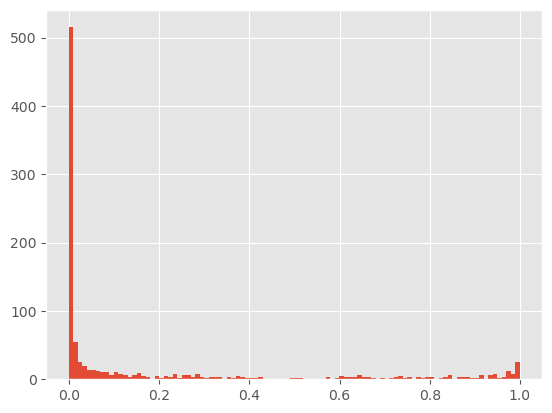

In [35]:
all_pax.prob_rs_tot.hist(bins=100)
plt.show()

In [36]:
inData.sblts.rides

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest,degree,index
0,[0],14.311111,805,1,[14.31111111111111],"[0, 805]",[0],[0],1.0,0
1,[1],11.549778,649,1,[11.549777777777777],"[5, 649]",[1],[1],1.0,1
2,[2],6.733500,378,1,[6.7335],"[24, 378]",[2],[2],1.0,2
3,[3],6.140833,345,1,[6.140833333333333],"[63, 345]",[3],[3],1.0,3
4,[4],3.669722,206,1,[3.6697222222222226],"[78, 206]",[4],[4],1.0,4
...,...,...,...,...,...,...,...,...,...,...
39813,"[304, 298, 323]",29.799667,1931,32,"[17.503805555555555, 8.052305555555556, 4.2435...","[5789.0, 233, 458, 111, 308, 821]","[304, 298, 323]","[298, 323, 304]",NaN,39813
39814,"[304, 298, 326]",31.075583,1881,32,"[17.431583333333336, 8.232861111111111, 5.4111...","[5789.0, 233, 396, 214, 285, 753]","[304, 298, 326]","[298, 326, 304]",NaN,39814
39815,"[304, 330, 331]",28.661083,1958,32,"[18.23575, 6.824222222222223, 3.6011111111111114]","[5997.5, 409, 485, 134, 136, 794]","[304, 330, 331]","[330, 331, 304]",NaN,39815
39816,"[304, 330, 332]",29.784264,1911,32,"[18.105194444444443, 6.902000000000001, 4.7770...","[5997.5, 409, 455, 192, 120, 735]","[304, 330, 332]","[330, 332, 304]",NaN,39816


In [37]:
inData.sblts.requests.head(50)

,index,pax_id,origin,destination,treq,tdep,ttrav,tarr,tdrop,shareable,schedule_id,dist,car_park_cost,dest_center,platform,VoT,delta,u,u_PT
0,0,0,252315496,46380158,0,NaN,805,2021-11-01 08:13:35,NaN,False,NaN,8050,15.0,True,0,0.002778,600.000,14.311111,999999
1,1,1,4422115072,46351183,5,NaN,649,2021-11-01 08:11:04,NaN,False,NaN,6498,15.0,True,0,0.002778,600.000,11.549778,999999
2,2,2,46257961,46380093,24,NaN,378,2021-11-01 08:06:52,NaN,False,NaN,3789,15.0,True,0,0.002778,511.515,6.733500,999999
3,3,3,46332982,46314424,63,NaN,345,2021-11-01 08:06:58,NaN,False,NaN,3455,7.5,False,0,0.002778,466.425,6.140833,999999
4,4,4,46380158,46424347,78,NaN,206,2021-11-01 08:04:54,NaN,False,NaN,2065,15.0,True,0,0.002778,278.775,3.669722,999999
5,5,5,46411016,46430144,121,NaN,641,2021-11-01 08:12:52,NaN,False,NaN,6412,15.0,True,0,0.002778,600.000,11.398556,999999
6,6,6,5656789643,1069290042,144,NaN,529,2021-11-01 08:11:23,NaN,False,NaN,5297,15.0,True,0,0.002778,600.000,9.414944,999999
7,7,7,46286182,5897198108,169,NaN,431,2021-11-01 08:10:10,NaN,False,NaN,4316,7.5,False,0,0.002778,582.660,7.671222,999999
8,8,8,46247649,46343363,172,NaN,308,2021-11-01 08:08:10,NaN,False,NaN,3081,15.0,True,0,0.002778,415.935,5.477056,999999
9,9,9,46428748,46390250,226,NaN,207,2021-11-01 08:07:23,NaN,False,NaN,2070,15.0,True,0,0.002778,279.450,3.680000,999999


In [38]:
inData.sblts.rides.tail(50)

,indexes,u_pax,u_veh,kind,u_paxes,times,indexes_orig,indexes_dest,degree,index
39768,"[304, 306, 331]",30.864000,2297,32,"[18.692694444444445, 8.321583333333333, 3.8497...","[5612.0, 787, 406, 205, 105, 794]","[304, 306, 331]","[306, 331, 304]",NaN,39768
39769,"[304, 306, 333]",31.613264,2294,32,"[18.628805555555555, 8.296583333333334, 4.687875]","[5612.0, 787, 348, 274, 127, 758]","[304, 306, 333]","[306, 333, 304]",NaN,39769
39770,"[304, 300, 329]",29.289250,2104,31,"[18.388527777777778, 7.015902777777778, 3.8848...","[5526.5, 766, 162, 244, 163, 769]","[304, 300, 329]","[329, 300, 304]",NaN,39770
39771,"[304, 311, 322]",28.793778,1674,32,"[16.984361111111113, 4.224402777777778, 7.5850...","[5920.0, 235, 174, 209, 458, 598]","[304, 311, 322]","[311, 322, 304]",NaN,39771
39772,"[304, 311, 334]",27.322583,1544,32,"[16.870472222222222, 3.810513888888889, 6.6415...","[5920.0, 235, 279, 38, 405, 587]","[304, 311, 334]","[311, 334, 304]",NaN,39772
39773,"[304, 311, 312]",24.458139,1567,32,"[16.603805555555557, 4.338291666666667, 3.5160...","[5920.0, 235, 345, 49, 237, 701]","[304, 311, 312]","[311, 312, 304]",NaN,39773
39774,"[304, 311, 317]",30.049667,2030,32,"[17.97325, 3.9827361111111115, 8.093680555555556]","[5920.0, 235, 40, 256, 366, 1133]","[304, 311, 317]","[311, 317, 304]",NaN,39774
39775,"[304, 288, 284]",36.102833,1880,32,"[18.539916666666667, 7.8235277777777785, 9.739...","[5592.0, 485, 105, 412, 323, 555]","[304, 288, 284]","[288, 284, 304]",NaN,39775
39776,"[304, 288, 308]",30.996778,2303,32,"[18.995472222222222, 7.951305555555556, 4.0500...","[5592.0, 485, 581, 131, 174, 932]","[304, 288, 308]","[288, 308, 304]",NaN,39776
39777,"[304, 288, 311]",30.815625,2264,32,"[18.831583333333334, 7.534638888888889, 4.4494...","[5592.0, 485, 445, 97, 299, 938]","[304, 288, 311]","[288, 311, 304]",NaN,39777


In [39]:
inData.passengers

,pos,event,platforms,ASC_bike,ASC_car,ASC_pt,VoT,U_bike,U_car,U_pt,ASC_rs,ASC_pool,mode_choice,prob_rs,prob_pool,informed,expected_wait,expected_wait_pool,expected_pool_disc,expected_pool_detour,mode_day
pax,,,,,,,,,,,,,,,,,,,,,
0,252315496,NaN,[0],-3.269107,-7.987493,-4.737945,4.977518,-5.294819,-15.921674,-99999,-2.742338,-2.993338,day-to-day,0.037665,0.346669,True,112.20,0.00,0.25,0.0,bike
1,4422115072,NaN,[0],-10.851341,-0.425604,-3.327160,6.138601,-12.865450,-8.214422,-99999,-3.337709,-3.588709,day-to-day,0.129879,0.780843,True,0.00,102.60,0.30,37.8,car
2,46257961,NaN,[0],-1.975421,-2.945768,-1.692718,16.337435,-5.097505,-11.700420,-99999,-5.635304,-5.886304,day-to-day,0.021097,0.060527,True,0.00,0.00,0.25,0.0,bike
3,46332982,NaN,[0],-6.787440,-7.258104,-3.648363,7.343581,-8.068283,-11.763194,-99999,-7.061884,-7.312884,day-to-day,0.109676,0.287546,True,60.84,0.00,0.25,0.0,bike
4,46380158,NaN,[0],-5.395861,-1.570870,-3.806122,3.103124,-5.719034,-7.846937,-99999,-6.511414,-6.762414,day-to-day,0.059484,0.106708,True,0.00,0.00,0.25,0.0,bike
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,506965966,NaN,[0],-0.790589,-0.518386,-4.027713,9.567935,-2.976968,-8.399212,-99999,-1.482747,-1.733747,day-to-day,0.086056,0.302160,True,0.00,0.00,0.25,0.0,bike
368,6235704571,NaN,[0],-6.373605,-5.068871,-3.935351,25.035097,-12.195656,-15.568073,-99999,-1.938595,-2.189595,day-to-day,0.217807,0.781653,True,45.80,206.48,0.29,0.0,pool
369,46302615,NaN,[0],-2.372959,-2.627474,-1.851965,4.286332,-3.638475,-9.923532,-99999,-3.704111,-3.955111,day-to-day,0.015690,0.078993,True,0.00,0.00,0.25,0.0,bike


In [40]:
inData.sblts.keys()

odict_keys(['log', 'requests', 'SINGLES', 'rides', 'R', 'FIFO2', 'LIFO2', 'pairs', 'S', 'schedule'])

In [41]:
inData.sblts.requests

,index,pax_id,origin,destination,treq,tdep,ttrav,tarr,tdrop,shareable,schedule_id,dist,car_park_cost,dest_center,platform,VoT,delta,u,u_PT
0,0,0,252315496,46380158,0,NaN,805,2021-11-01 08:13:35,NaN,False,NaN,8050,15.0,True,0,0.002778,600.000,14.311111,999999
1,1,1,4422115072,46351183,5,NaN,649,2021-11-01 08:11:04,NaN,False,NaN,6498,15.0,True,0,0.002778,600.000,11.549778,999999
2,2,2,46257961,46380093,24,NaN,378,2021-11-01 08:06:52,NaN,False,NaN,3789,15.0,True,0,0.002778,511.515,6.733500,999999
3,3,3,46332982,46314424,63,NaN,345,2021-11-01 08:06:58,NaN,False,NaN,3455,7.5,False,0,0.002778,466.425,6.140833,999999
4,4,4,46380158,46424347,78,NaN,206,2021-11-01 08:04:54,NaN,False,NaN,2065,15.0,True,0,0.002778,278.775,3.669722,999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,367,367,506965966,46372928,7067,NaN,452,2021-11-01 10:05:29,NaN,False,NaN,4524,15.0,True,0,0.002778,600.000,8.041556,999999
368,368,368,6235704571,46379144,7069,NaN,460,2021-11-01 10:05:39,NaN,False,NaN,4601,15.0,True,0,0.002778,600.000,8.179278,999999
369,369,369,46302615,46426761,7084,NaN,584,2021-11-01 10:07:58,NaN,False,NaN,5841,15.0,True,0,0.002778,600.000,10.383722,999999
370,370,370,46409976,46326256,7098,NaN,297,2021-11-01 10:03:25,NaN,False,NaN,2973,7.5,False,0,0.002778,401.355,5.284500,999999


In [42]:
poolers

[10,
 12,
 22,
 25,
 28,
 32,
 39,
 52,
 54,
 56,
 59,
 71,
 78,
 79,
 102,
 116,
 137,
 157,
 169,
 175,
 189,
 219,
 224,
 225,
 227,
 240,
 241,
 254,
 263,
 268,
 269,
 300,
 323,
 326,
 341,
 349,
 351,
 352,
 368]

In [16]:
inData.requests

,origin,destination,treq,tarr,ttrav,dist,haver_dist,ttrav_alb,schedule_id,shareable,tdep,pax_id,tdrop,car_park_cost,dest_center,platform
0,7890114045,413562329,2021-11-01 12:14:39,1900-01-01 12:48:00,0 days 00:20:25,12254,3263.899637,0 days 00:34:00,3,False,NaN,0,NaN,7.5,False,0
1,46432874,7890114045,2021-11-01 16:45:10,1900-01-01 17:13:00,0 days 00:17:54,10747,7271.601930,0 days 00:28:00,4,False,NaN,1,NaN,7.5,False,0
2,413562329,7890114045,2021-11-01 14:48:42,1900-01-01 14:53:00,0 days 00:19:28,11688,3263.899637,0 days 00:05:00,6,False,NaN,2,NaN,7.5,False,0
3,6219354473,46430021,2021-11-01 17:30:34,1900-01-01 18:01:00,0 days 00:13:18,7981,5319.408617,0 days 00:31:00,9,False,NaN,3,NaN,7.5,False,0
4,46385765,46566460,2021-11-01 09:05:09,1900-01-01 09:56:00,0 days 00:17:52,10721,6020.331560,0 days 00:51:00,16,False,NaN,4,NaN,7.5,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,46307092,46278428,2021-11-01 15:24:48,1900-01-01 16:09:00,0 days 00:13:27,8072,6279.332681,0 days 00:45:00,980,False,NaN,334,NaN,7.5,False,0
335,46248282,2054127618,2021-11-01 09:02:15,1900-01-01 09:13:00,0 days 00:08:37,5175,4185.449560,0 days 00:11:00,984,False,NaN,335,NaN,7.5,False,0
336,46247279,46247628,2021-11-01 14:31:02,1900-01-01 14:58:00,0 days 00:08:38,5181,3621.826351,0 days 00:27:00,985,False,NaN,336,NaN,7.5,False,0
337,46434758,46244537,2021-11-01 13:37:56,1900-01-01 13:48:00,0 days 00:10:49,6490,4882.008447,0 days 00:11:00,993,False,NaN,337,NaN,7.5,False,0


In [17]:
inData.sblts.requests

,index,origin,destination,treq,tarr,ttrav,dist,haver_dist,ttrav_alb,schedule_id,shareable,tdep,pax_id,tdrop,car_park_cost,dest_center,platform,VoT,delta,u,u_PT
0,191,46388158,46305534,0,1900-01-01 09:07:00,285,2854,2150.742047,0 days 00:06:00,554,False,NaN,191,NaN,7.5,False,0,0.002778,385.290,5.072667,999999
1,335,46248282,2054127618,65,1900-01-01 09:13:00,517,5175,4185.449560,0 days 00:11:00,984,False,NaN,335,NaN,7.5,False,0,0.002778,600.000,9.198611,999999
2,113,1587126024,46330781,144,1900-01-01 09:11:00,262,2623,2077.797101,0 days 00:08:00,337,False,NaN,113,NaN,15.0,True,0,0.002778,354.105,4.662278,999999
3,217,46364379,290929444,200,1900-01-01 09:21:00,696,6969,3070.323806,0 days 00:17:00,635,False,NaN,217,NaN,7.5,False,0,0.002778,600.000,12.386833,999999
4,4,46385765,46566460,239,1900-01-01 09:56:00,1072,10721,6020.331560,0 days 00:51:00,16,False,NaN,4,NaN,7.5,False,0,0.002778,600.000,19.059278,999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,323,30154649,1673400142,32090,1900-01-01 18:01:00,335,3357,2298.996935,0 days 00:05:00,948,False,NaN,323,NaN,7.5,False,0,0.002778,453.195,5.966056,999999
335,82,350472299,46419761,32141,1900-01-01 18:01:00,451,4512,3051.166799,0 days 00:05:00,258,False,NaN,82,NaN,7.5,False,0,0.002778,600.000,8.020778,999999
336,247,2013949658,46313235,32193,1900-01-01 18:11:00,255,2550,2193.432690,0 days 00:14:00,726,False,NaN,247,NaN,7.5,False,0,0.002778,344.250,4.533333,999999
337,245,46402528,46288517,32209,1900-01-01 18:13:00,402,4022,2924.538271,0 days 00:16:00,718,False,NaN,245,NaN,7.5,False,0,0.002778,542.970,7.149667,999999


In [18]:
inData.passengers

,pos,event,platforms,ASC_bike,ASC_car,ASC_pt,VoT,U_bike,U_car,U_pt,ASC_rs,ASC_pool,mode_choice,prob_rs,prob_pool,informed,expected_wait,expected_wait_pool,expected_pool_disc,expected_pool_detour
0,NaN,NaN,[0],-3.269107,-7.987493,-4.737945,4.977518,-6.351712,-14.167452,-3647.751837,-2.742338,-2.993338,day-to-day,0.010048,0.291094,True,0,0,0.25,0
1,NaN,NaN,[0],-10.851341,-0.425604,-3.327160,6.138601,-14.184397,-6.521712,-8.097049,-3.337709,-3.588709,day-to-day,0.012595,0.241614,True,0,0,0.25,0
2,NaN,NaN,[0],-1.975421,-2.945768,-1.692718,16.337435,-11.622495,-11.713218,-3652.415791,-5.635304,-5.886304,day-to-day,0.016838,0.417508,True,0,0,0.25,0
3,NaN,NaN,[0],-6.787440,-7.258104,-3.648363,7.343581,-9.750086,-12.924014,-9.017053,-7.061884,-7.312884,day-to-day,0.016189,0.146181,True,0,0,0.25,0
4,NaN,NaN,[0],-9.489443,-1.829747,-2.418385,8.005449,-13.828040,-8.349834,-8.476124,-0.170290,-0.421290,day-to-day,0.047995,0.915676,True,0,0,0.25,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,NaN,NaN,[0],-6.373605,-5.068871,-3.935351,25.035097,-16.587507,-14.347983,-20.777400,-1.938595,-2.189595,day-to-day,0.097471,0.902048,True,0,0,0.25,0
335,NaN,NaN,[0],-2.372959,-2.627474,-1.851965,4.286332,-3.493287,-7.042555,-4.659026,-3.704111,-3.955111,day-to-day,0.015306,0.064177,True,0,0,0.25,0
336,NaN,NaN,[0],-4.842188,-7.644697,-1.977186,10.353199,-7.553461,-13.115900,-6.223365,-6.366459,-6.617459,day-to-day,0.012732,0.053531,True,0,0,0.25,0
337,NaN,NaN,[0],-7.303342,-2.295302,-3.471872,10.053120,-10.601827,-8.085958,-9.919226,-2.687889,-2.938889,day-to-day,0.130539,0.784812,True,0,0,0.25,0
